In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample  #downsample the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
df=pd.read_excel("/content/sample_data/default of credit card clients.xls",header=1)

In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [6]:
df.rename({"default payment next month":"DEFAULT"},axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

In [7]:
df.drop('ID',axis=1,inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

In [8]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

In [10]:
df['SEX'].unique()

array([2, 1])

In [11]:
df['EDUCATION'].unique()

array([2, 1, 3, 5, 4, 6, 0])

In [12]:
df["MARRIAGE"].unique()

array([1, 2, 3, 0])

In [13]:
#missing data
len(df.loc[(df['EDUCATION']==0) | (df["MARRIAGE"]==0)])

68

In [14]:
len(df.loc[(df['EDUCATION']!=0) & (df["MARRIAGE"]!=0)])

29932

In [15]:
df_clean=df.loc[(df['EDUCATION']!=0) & (df["MARRIAGE"]!=0)]

In [16]:
df_clean['EDUCATION'].unique()

array([2, 1, 3, 5, 4, 6])

In [17]:
#downsample
len(df_clean)

29932

In [18]:
df_no_default=df_clean[df_clean['DEFAULT']==0]
df_default=df_clean[df_clean['DEFAULT']==1]

In [19]:
df_no_default.shape

(23301, 24)

In [20]:
df_default.shape

(6631, 24)

In [21]:
df_no_default_downsample=resample(df_no_default,replace=False,n_samples=1000, random_state=2)
len(df_no_default_downsample)

1000

In [22]:
df_default_downsample=resample(df_default,replace=False,n_samples=1000, random_state=2)
len(df_default_downsample)

1000

In [23]:
df_downsample=pd.concat([df_no_default_downsample,df_default_downsample])
len(df_downsample)

2000

In [24]:
#split the data as X and y
X=df_downsample.drop('DEFAULT',axis=1).copy()
X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
7315,200000,1,2,2,44,-1,-1,-1,-1,-1,...,1230,3393,1340,3416,2306,1234,3510,1344,3426,6324
27225,90000,1,2,1,31,0,0,2,0,0,...,91508,86167,49479,50704,20000,0,3752,1726,2003,2000
29067,120000,2,3,1,50,0,0,0,0,0,...,112482,115046,80987,85921,5500,4200,4552,3100,6416,0
22159,230000,2,1,2,29,-2,-2,-2,-2,-2,...,0,0,100,900,0,0,0,100,900,715
22218,250000,2,1,2,26,0,0,0,0,0,...,43194,41381,33246,32948,2027,2020,1510,1000,1000,7000


In [25]:
y=df_downsample['DEFAULT'].copy()
y.head()

,DEFAULT
7315,0
27225,0
29067,0
22159,0
22218,0


In [26]:
#one hot encoding
pd.get_dummies(X, columns=['MARRIAGE']).head()

,LIMIT_BAL,SEX,EDUCATION,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,...,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
7315,200000,1,2,44,-1,-1,-1,-1,-1,-1,...,3416,2306,1234,3510,1344,3426,6324,False,True,False
27225,90000,1,2,31,0,0,2,0,0,0,...,50704,20000,0,3752,1726,2003,2000,True,False,False
29067,120000,2,3,50,0,0,0,0,0,0,...,85921,5500,4200,4552,3100,6416,0,True,False,False
22159,230000,2,1,29,-2,-2,-2,-2,-2,-2,...,900,0,0,0,100,900,715,False,True,False
22218,250000,2,1,26,0,0,0,0,0,0,...,32948,2027,2020,1510,1000,1000,7000,False,True,False


In [27]:
df_downsample.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT'],
      dtype='object')

In [28]:
X_encoded=pd.get_dummies(X, columns=['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'])
X_encoded.head()

,LIMIT_BAL,SEX_1,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,...,PAY_AMT6_148225,PAY_AMT6_150000,PAY_AMT6_158064,PAY_AMT6_159259,PAY_AMT6_170000,PAY_AMT6_177258,PAY_AMT6_196000,PAY_AMT6_201134,PAY_AMT6_250000,PAY_AMT6_280000
7315,200000,True,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
27225,90000,True,False,False,True,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
29067,120000,False,True,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
22159,230000,False,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
22218,250000,False,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [29]:
X_train,X_test,y_train,y_test=train_test_split(X_encoded,y,random_state=2)
X_train_scaled=scale(X_train)
X_test_scaled=scale(X_test)

In [30]:
#SVM
svm_model=SVC(random_state=2)


In [36]:
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=2)

In [37]:
y_pred=svm_model.predict(X_test_scaled)

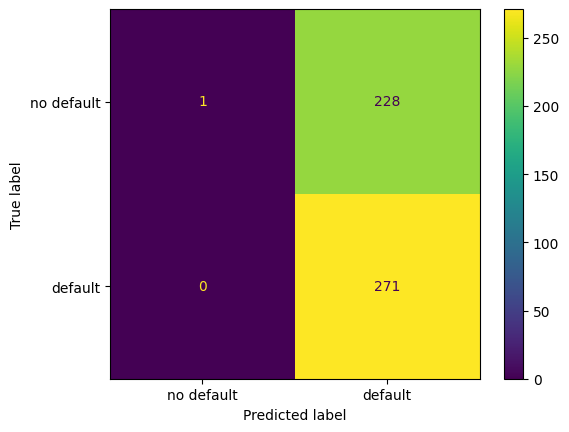

In [48]:
cm = confusion_matrix(y_test, y_pred)
po=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no default','default'])
po.plot()

In [49]:
param_grid=[{'C':[0.5,1,10,100],
            'gamma':['scale',1,0.1,.01,0.001,0.0001],
            'kernel':['rbf']}]

In [50]:
opt_param=GridSearchCV(SVC(),param_grid,cv=5,scoring='accuracy',verbose=0)

In [51]:
opt_param.fit(X_train_scaled,y_train)

KeyboardInterrupt: 

In [ ]:
print(opt_param._best_score)